# 04 — Exploratory Data Analysis & Visualization

**Author:** Kuthab Ibrahim  
**Goal:** Use the cleaned datasets to (1) compute the analytical features (workload score, PER, age band, injury flag), (2) produce the six required plots, and (3) walk through two career case studies.

All charts are saved to `outputs/figures/` via the shared styling in `src/visualizer.py`.  
All quantitative claims in the project report (`outputs/report.md`) come from this notebook.

In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
from src import cleaner, visualizer as vz

FIGURES_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'figures')
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
vz.setup_style()
pd.set_option('display.max_columns', 30)

## 1. Load cleaned data

Prefer the processed CSVs written by notebook 02. If they're missing (e.g., running this notebook in isolation), fall back to running the cleaner on the raw CSVs.

In [3]:
stats_path = os.path.join(PROCESSED_DIR, 'player_stats_clean.csv')
inj_path   = os.path.join(PROCESSED_DIR, 'injuries_clean.csv')

if os.path.exists(stats_path) and os.path.exists(inj_path):
    stats = pd.read_csv(stats_path)
    injuries = pd.read_csv(inj_path)
else:
    result = cleaner.cleaner()
    stats, injuries = result['player_stats'], result['injuries']

print('player-seasons:', len(stats))
print('injury rows   :', len(injuries))

player-seasons: 11659
injury rows   : 18950


## 2. Compute analytical features

Same definitions used in `src/features.py` and the report:

- **Workload Score** = `(MPG / season_max_MPG) × (games_played / 82)` — bounded in `[0,1]`.
- **PER (proxy)** = `(PTS + AST + REB + BLK + STL) / MPG` — a simple efficiency proxy in lieu of the licensed Hollinger PER.
- **Usage Rate (proxy)** = `PTS / MPG`.
- **Injury Flag** = 1 if total games missed in a season ≥ 10, else 0.
- **Age Bands** = `under 25 / 25–29 / 30–33 / 34+`.

In [4]:
stats['season_year'] = stats['season'].astype(str).str[:4].astype(int)
season_max_mpg = stats.groupby('season')['minutes_per_game'].transform('max')
stats['workload_score'] = (stats['minutes_per_game'] / season_max_mpg) * (stats['games_played'] / 82)
stats['workload_score'] = stats['workload_score'].clip(lower=0, upper=1)

stats['per'] = (stats['points_per_game'] + stats['assists_per_game']
                + stats['rebounds_per_game'] + stats['blocks_per_game']
                + stats['steals_per_game']) / stats['minutes_per_game'].replace(0, np.nan)
stats['usage_rate'] = stats['points_per_game'] / stats['minutes_per_game'].replace(0, np.nan)
stats = stats.sort_values(['player_id', 'season_year'])
stats['per_change'] = stats.groupby('player_id')['per'].diff()

stats['age_risk_factor'] = pd.cut(stats['age'], bins=[0,24,29,33,100],
                                  labels=['under 25', '25-29', '30-33', '34+'])

season_inj = (injuries.dropna(subset=['player_id'])
                       .groupby(['player_id','season'])['games_missed']
                       .sum().reset_index().rename(columns={'games_missed':'total_games_missed'}))
stats['player_id'] = stats['player_id'].astype('Int64')
stats = stats.merge(season_inj, on=['player_id','season'], how='left')
stats['total_games_missed'] = stats['total_games_missed'].fillna(0).astype(int)
stats['injury_flag'] = (stats['total_games_missed'] >= 10).astype(int)

# Bucket position into the standard 5 (the league-dash feed is sparse here).
stats['position'] = stats['position'].fillna('UNK').astype(str).str.upper().str[:1]
stats.loc[~stats['position'].isin(['G','F','C']), 'position'] = 'UNK'

stats[['season','workload_score','per','per_change','injury_flag','age_risk_factor']].describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
season,11659,24,2021-22,605,NaN,NaN,NaN,NaN,NaN,NaN,NaN
workload_score,11659.0,NaN,NaN,NaN,0.361652,0.266234,0.000019,0.112841,0.337735,0.579332,1.0
per,11659.0,NaN,NaN,NaN,0.691649,0.192684,0.0,0.577945,0.674157,0.789584,5.806452
per_change,9282.0,NaN,NaN,NaN,-0.003435,0.14226,-5.341696,-0.06631,-0.00478,0.061145,2.071367
injury_flag,11659.0,NaN,NaN,NaN,0.305515,0.460645,0.0,0.0,0.0,1.0,1.0
age_risk_factor,11659,4,25-29,4504,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Sanity check** — a quick look at the league-wide injury rate. A real-world expectation is ~25–35% of player-seasons cross the 10-games-missed threshold.

In [5]:
rate = stats['injury_flag'].mean() * 100
print(f'League injury rate (>=10 games missed): {rate:.1f}%')
print(f'Mean workload score                : {stats["workload_score"].mean():.3f}')
print(f'Player-seasons with non-null PER    : {stats["per"].notna().sum():,}')

League injury rate (>=10 games missed): 30.6%
Mean workload score                : 0.362
Player-seasons with non-null PER    : 11,659


## 3. Plot 1 — Workload Score Distribution

saved: outputs\figures\workload_distribution.png


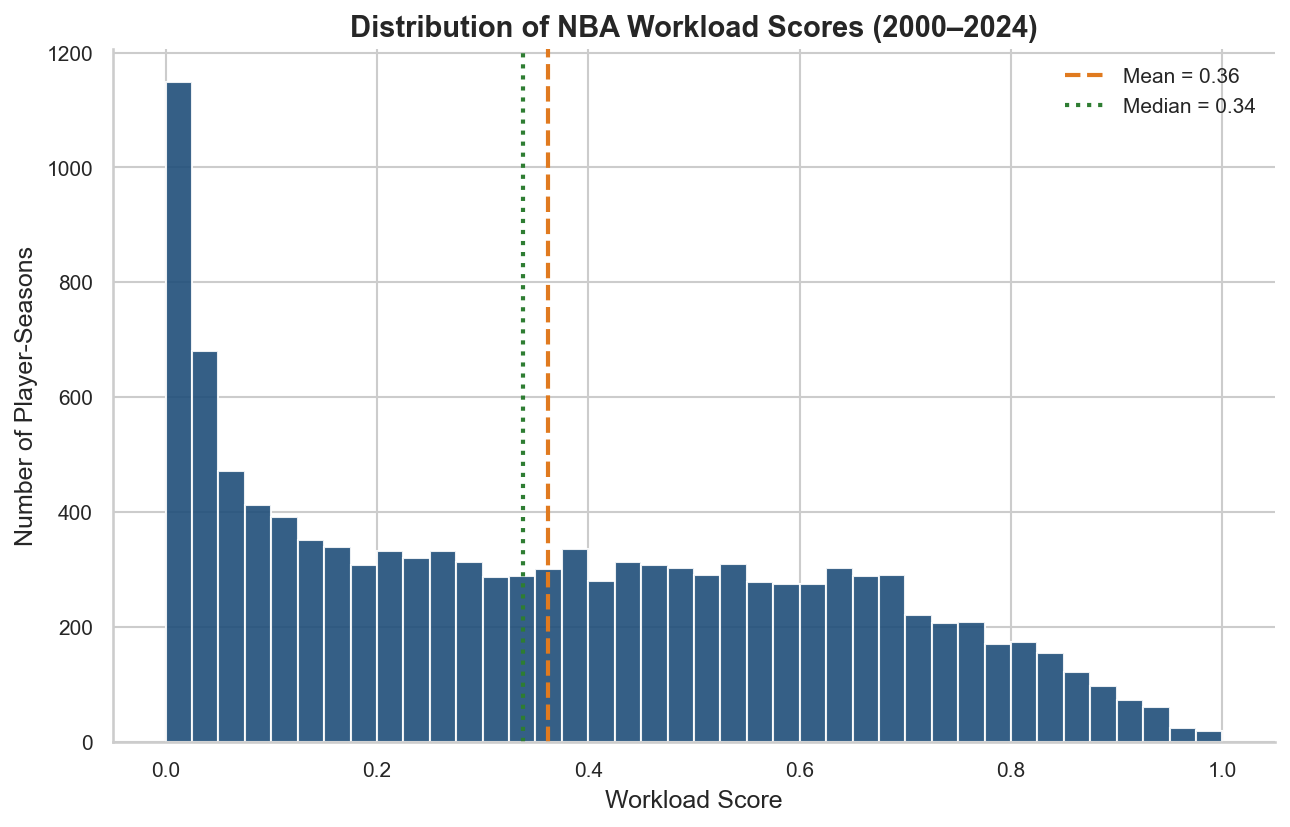

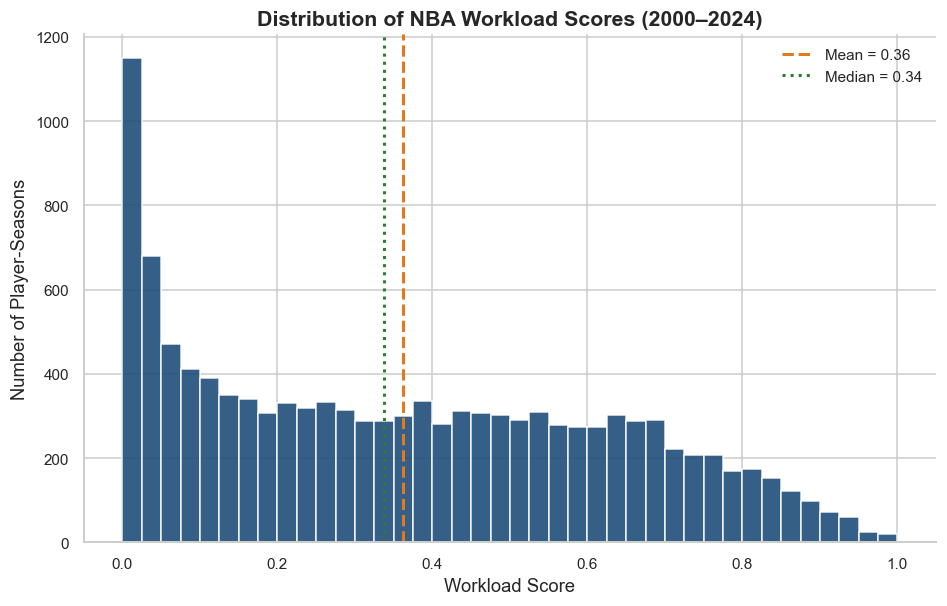

In [6]:
p = vz.plot_workload_distribution(stats); print('saved:', os.path.relpath(p, PROJECT_ROOT))
from IPython.display import Image
Image(p)

## 4. Plot 2 — Injury Rate by Workload Quintile

Splitting workload into five equal-sized buckets exposes the dose-response between minutes load and injury risk.

saved: outputs\figures\injury_rate_by_workload_quintile.png


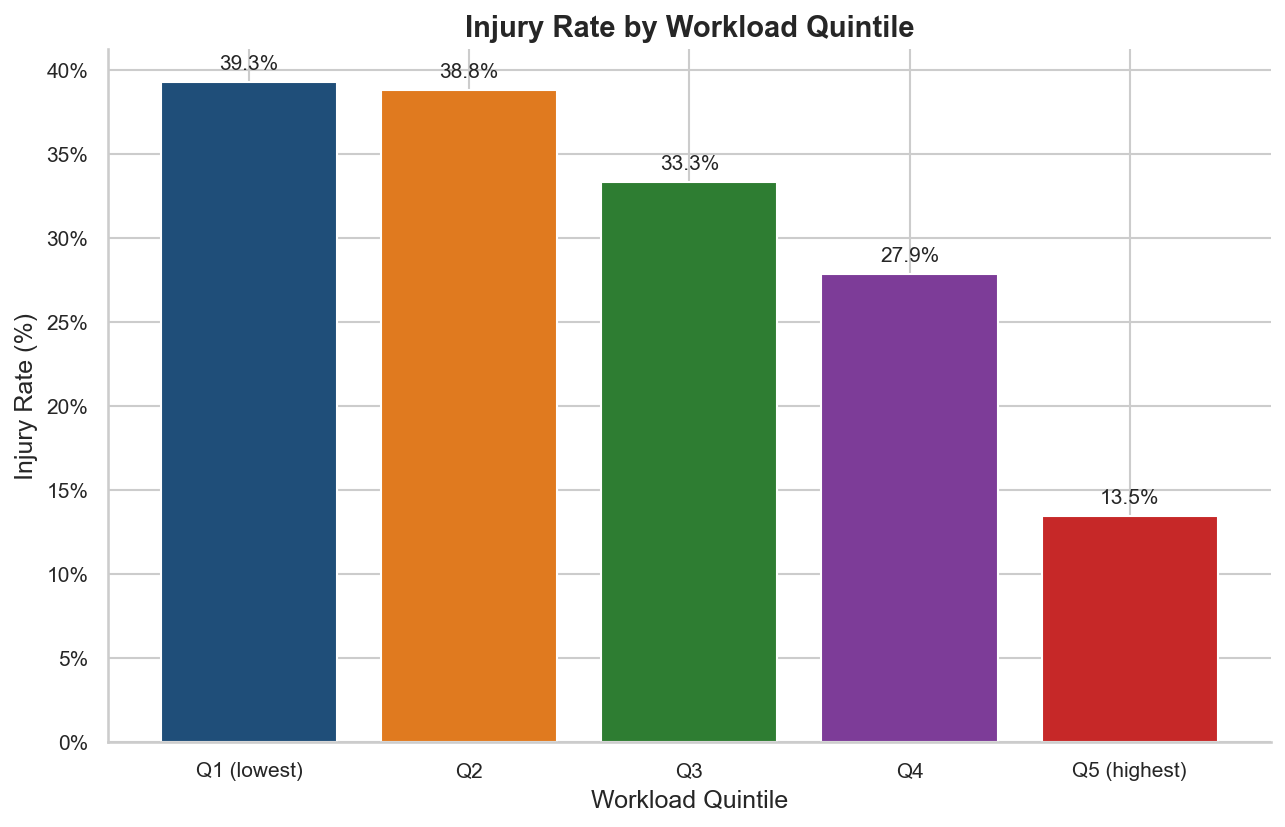

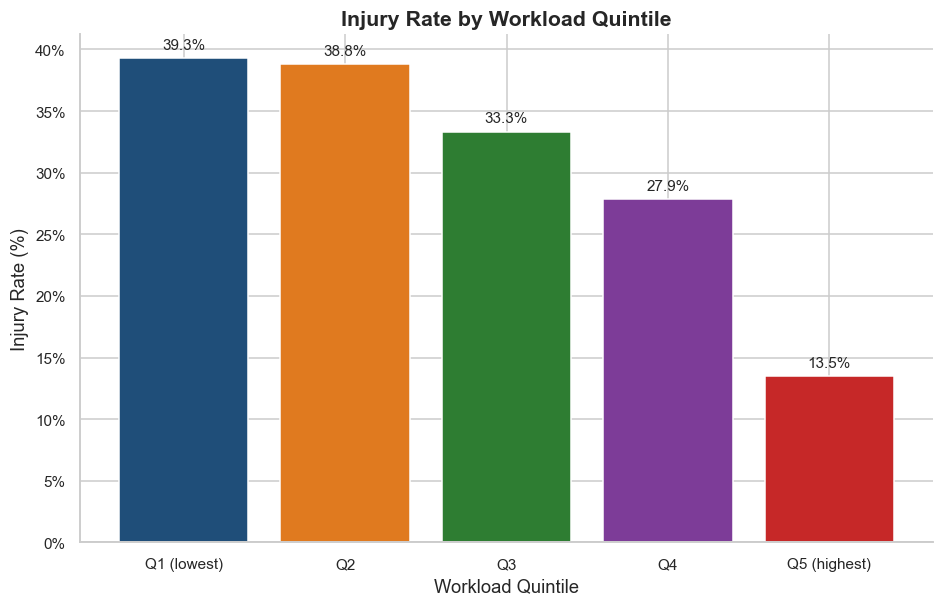

In [7]:
p = vz.plot_injury_rate_by_workload_quintile(stats); print('saved:', os.path.relpath(p, PROJECT_ROOT))
Image(p)

## 5. Plot 3 — Correlation Heatmap

saved: outputs\figures\correlation_heatmap.png


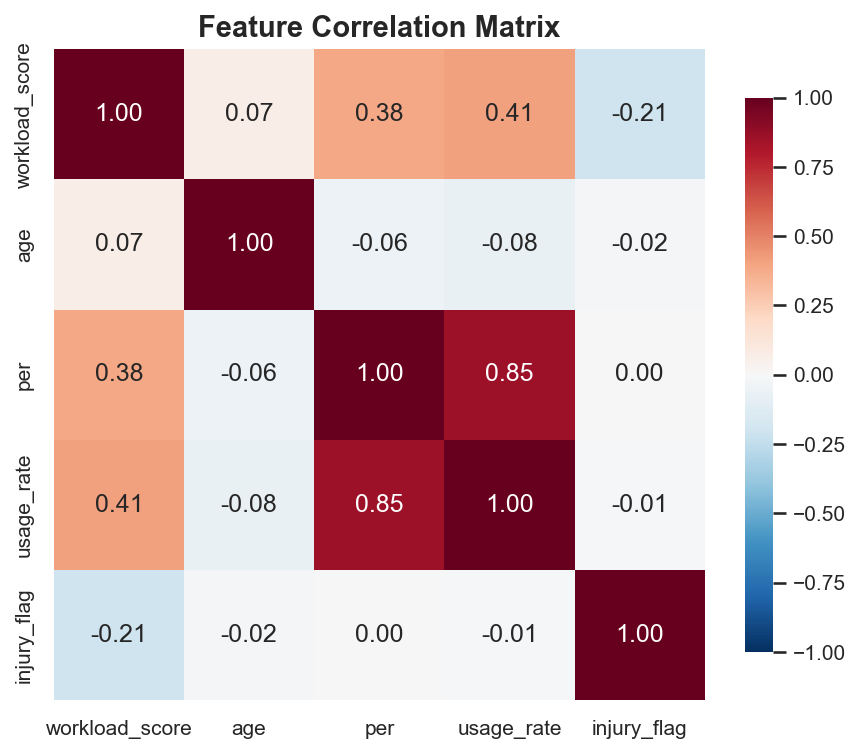

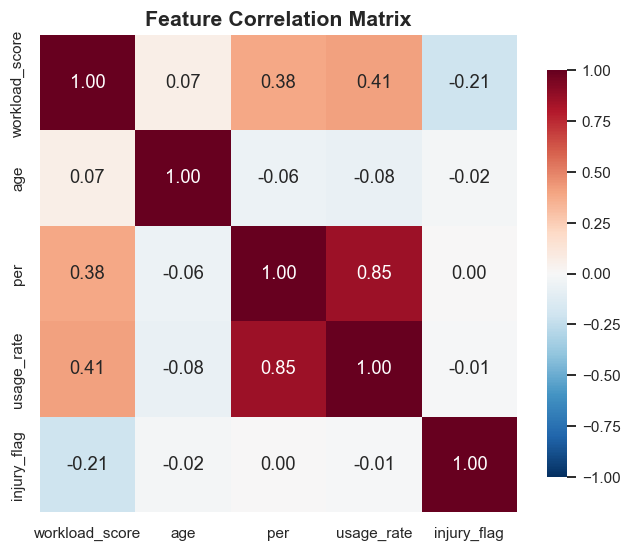

In [8]:
p = vz.plot_correlation_heatmap(stats, columns=['workload_score','age','per','usage_rate','injury_flag'])
print('saved:', os.path.relpath(p, PROJECT_ROOT))
Image(p)

## 6. Plot 4 — Injury Rate by Age Band & Position

Note: position is sparse in the nba.com league-dash feed and shows up as UNK for most players. We display the available bins; a future enrichment step (joining a roster file) would make this richer.

saved: outputs\figures\injury_rate_by_age_position.png


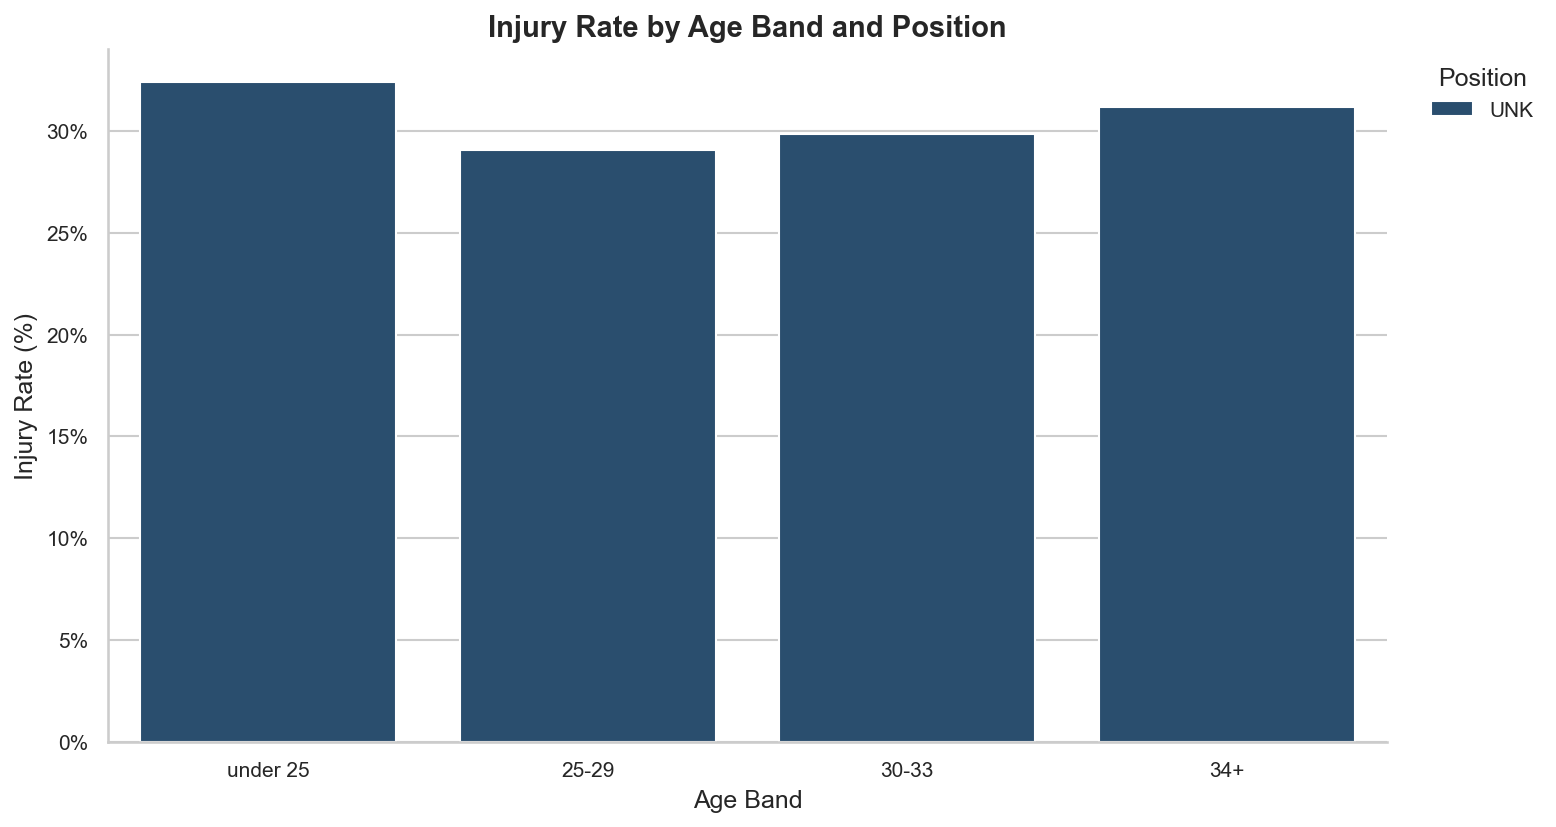

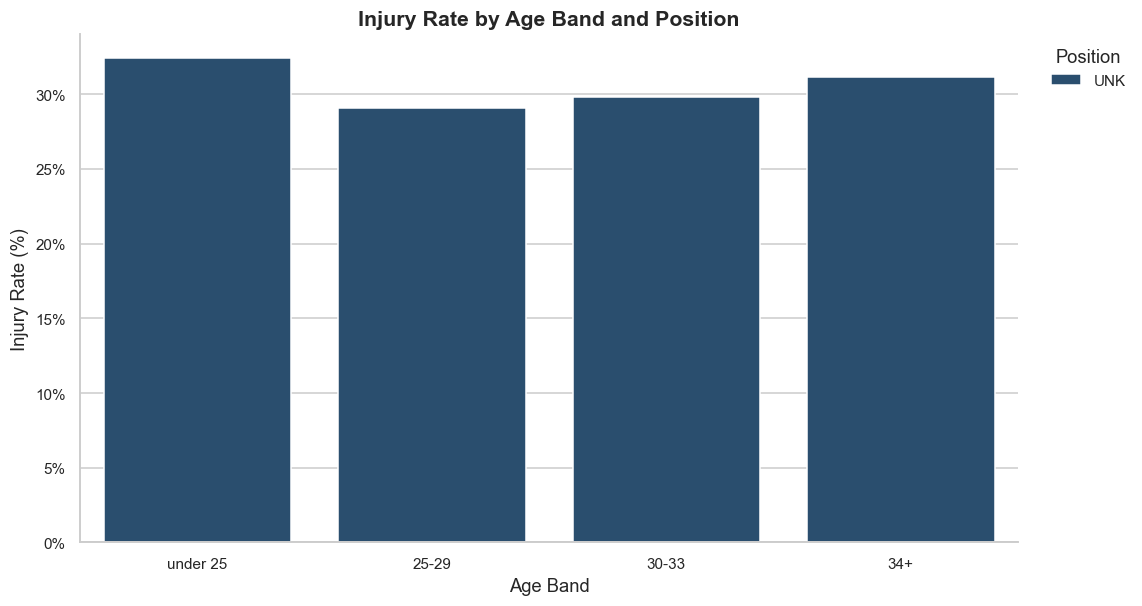

In [9]:
p = vz.plot_injury_rate_by_age_position(stats); print('saved:', os.path.relpath(p, PROJECT_ROOT))
Image(p)

## 7. Plot 5 — Year-over-Year PER Change by Workload Category

saved: outputs\figures\per_change_by_workload.png


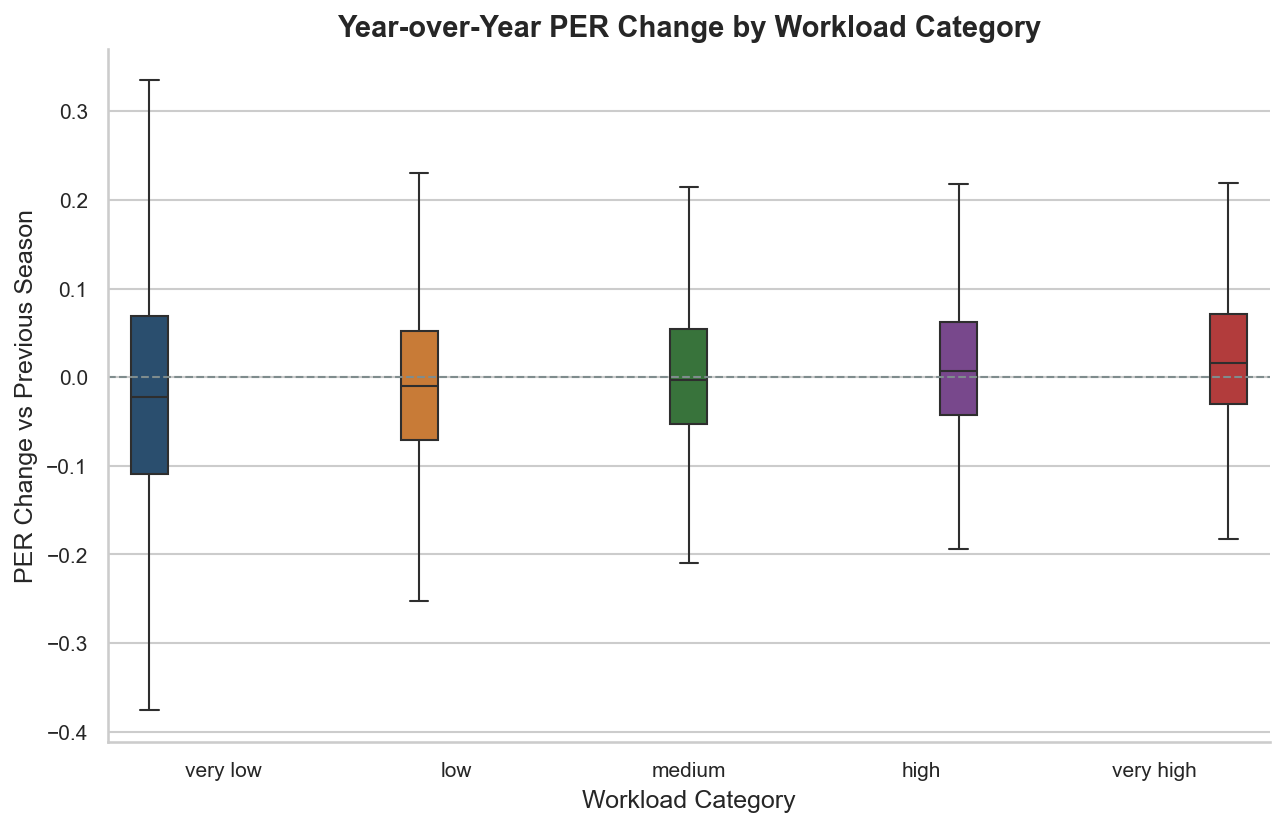

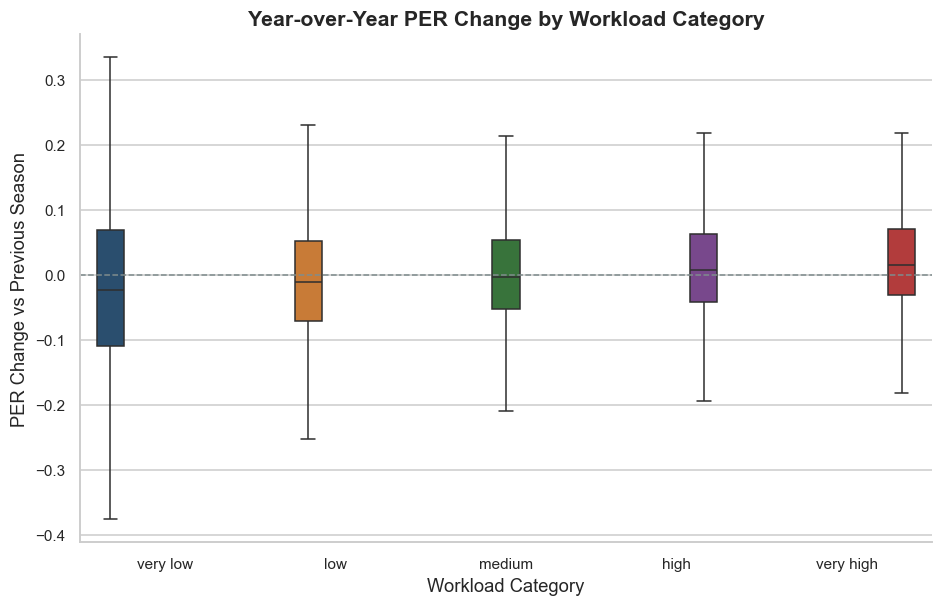

In [10]:
p = vz.plot_per_change_by_workload(stats); print('saved:', os.path.relpath(p, PROJECT_ROOT))
Image(p)

## 8. Plot 6 — Workload vs Injury Rate Across NBA Eras (2000–2024)

saved: outputs\figures\workload_injury_by_era.png


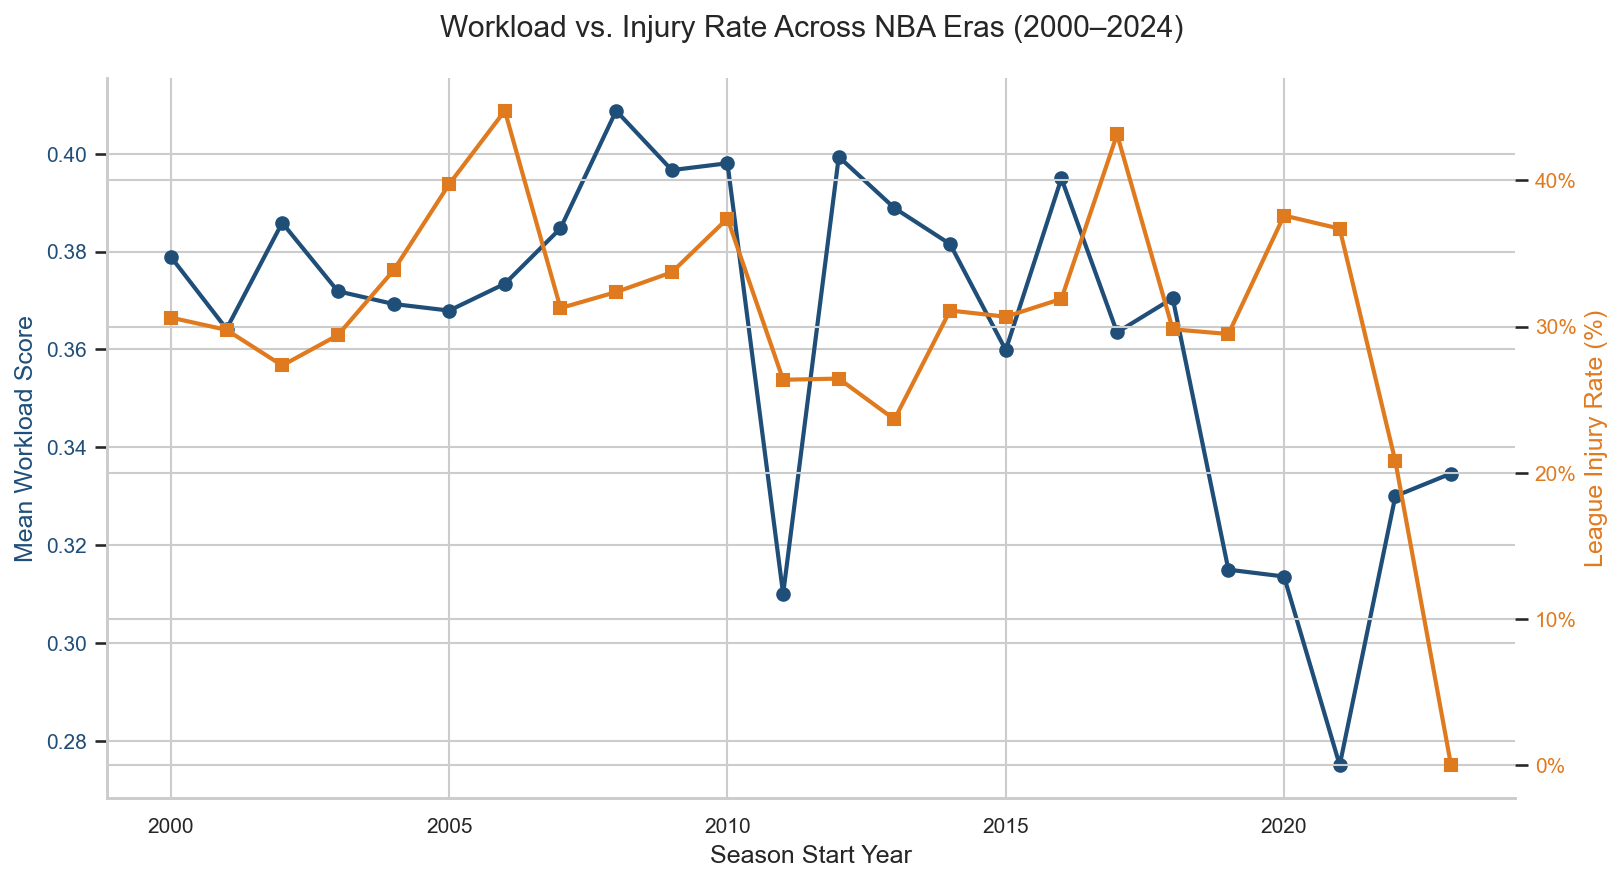

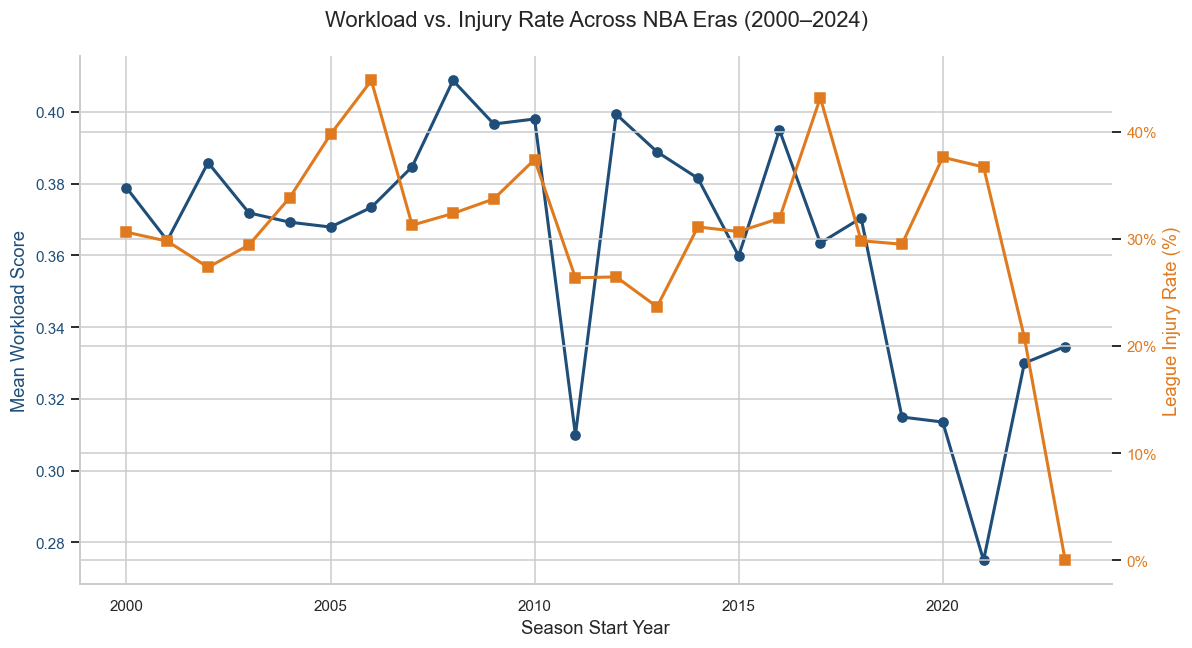

In [11]:
p = vz.plot_workload_vs_injury_by_era(stats); print('saved:', os.path.relpath(p, PROJECT_ROOT))
Image(p)

## 9. Career Case Studies

Two players whose careers exemplify opposite philosophies of workload management.

### 9.1 LeBron James — "Iron man" workload

LeBron has historically run a heavy minutes load year after year. The chart below shows his per-season workload score and marks any season that crossed the 10-games-missed injury threshold.

In [12]:
lebron = stats[stats['player_name_norm'] == 'lebron james'].sort_values('season_year').copy()
print(f'Seasons in dataset: {len(lebron)}')
lebron[['season','team','age','games_played','minutes_per_game','workload_score','total_games_missed','injury_flag']]

Seasons in dataset: 21


,season,team,age,games_played,minutes_per_game,workload_score,total_games_missed,injury_flag
3570,2003-04,CLE,19.0,79,39.580570,0.894236,0,0
3571,2004-05,CLE,20.0,80,42.299604,0.974498,0,0
3572,2005-06,CLE,21.0,79,42.539451,0.950888,115,1
3573,2006-07,CLE,22.0,78,40.901154,0.915842,3,0
3574,2007-08,CLE,23.0,75,40.357311,0.884045,279,1
3575,2008-09,CLE,24.0,81,37.704486,0.934259,0,0
3576,2009-10,CLE,25.0,76,39.022763,0.874595,116,1
3577,2010-11,MIA,26.0,79,38.771920,0.926116,1,0
3578,2011-12,MIA,27.0,62,37.519597,0.719543,0,0
3579,2012-13,MIA,28.0,76,37.855987,0.906499,0,0


saved: outputs\figures\career_lebron_james.png


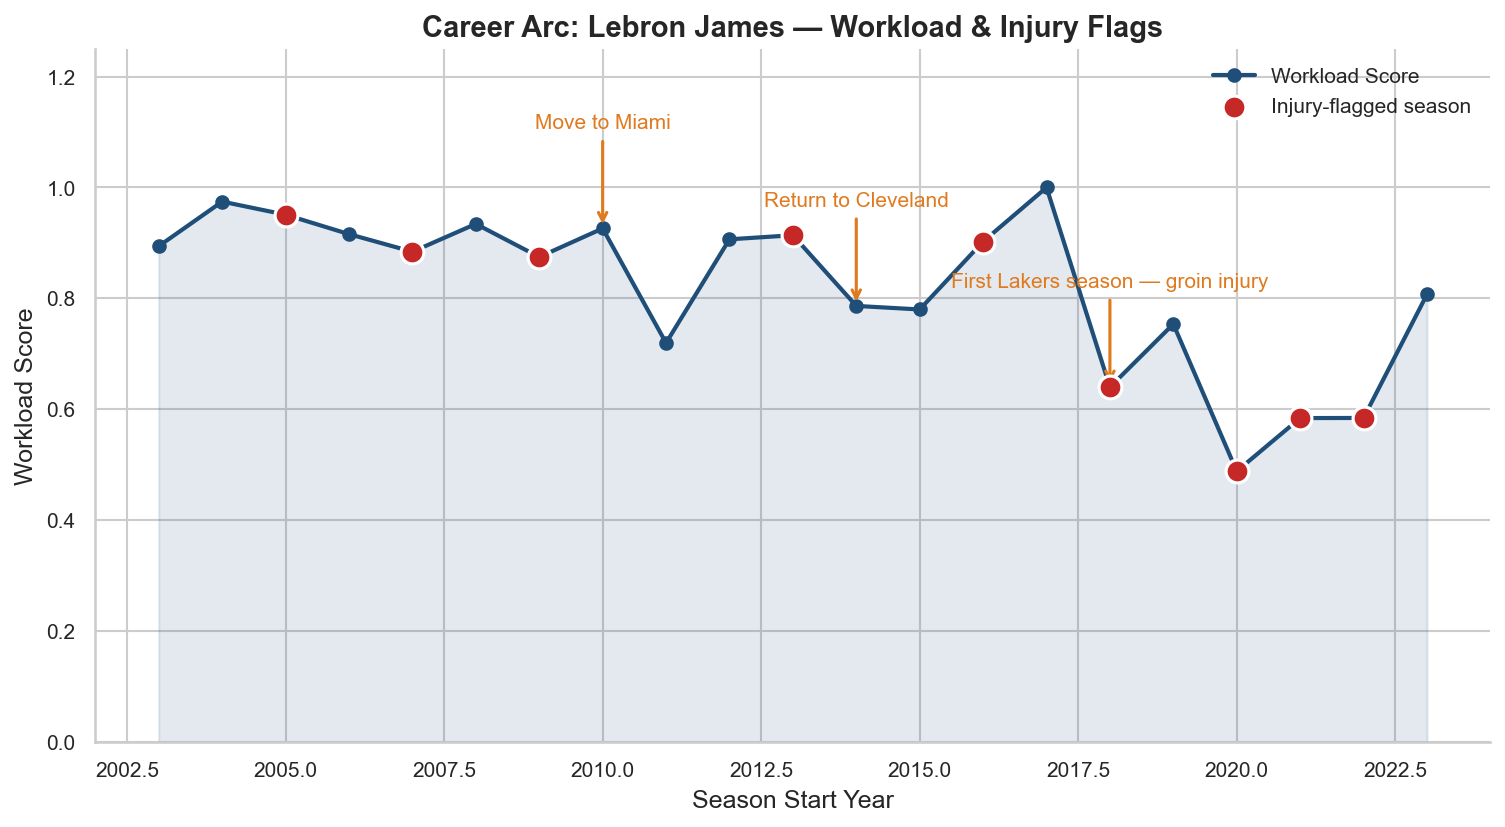

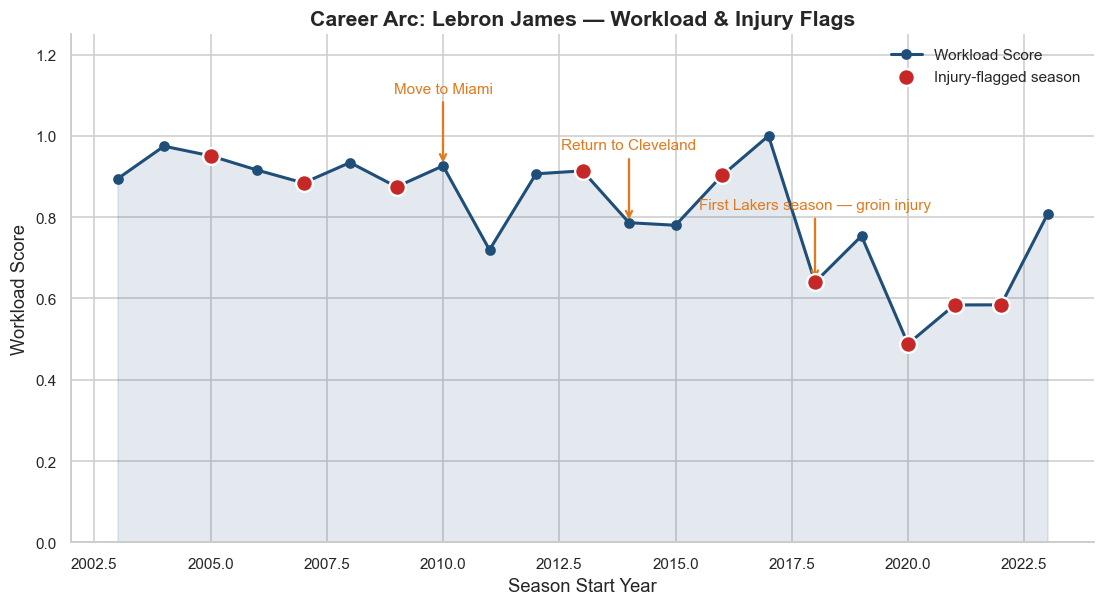

In [13]:
lebron_annotations = {
    '2010-11': 'Move to Miami',
    '2014-15': 'Return to Cleveland',
    '2018-19': 'First Lakers season — groin injury',
}
p = vz.plot_player_career(stats, 'lebron james', annotations=lebron_annotations)
print('saved:', os.path.relpath(p, PROJECT_ROOT))
Image(p)

### 9.2 Kawhi Leonard — "Load management"

Kawhi is the canonical load-management case. The 2017–18 season with the Spurs (he played 9 games) and the 2018–19 Raptors title season (he sat in 22 of 82 regular-season games) are explicitly annotated below.

In [14]:
kawhi = stats[stats['player_name_norm'] == 'kawhi leonard'].sort_values('season_year').copy()
print(f'Seasons in dataset: {len(kawhi)}')
kawhi[['season','team','age','games_played','minutes_per_game','workload_score','total_games_missed','injury_flag']]

Seasons in dataset: 12


,season,team,age,games_played,minutes_per_game,workload_score,total_games_missed,injury_flag
7393,2011-12,SAS,21.0,64,23.974948,0.474618,1,0
7394,2012-13,SAS,22.0,58,31.209167,0.570334,13,1
7395,2013-14,SAS,23.0,66,29.129924,0.605469,14,1
7396,2014-15,SAS,24.0,64,31.764063,0.641123,13,1
7397,2015-16,SAS,25.0,72,33.049491,0.685220,4,0
7398,2016-17,SAS,26.0,74,33.438919,0.799072,4,0
7399,2017-18,SAS,27.0,9,23.317963,0.069362,138,1
7400,2018-19,TOR,28.0,60,34.003056,0.673850,10,1
7401,2019-20,LAC,29.0,57,32.422953,0.601338,6,0
7402,2020-21,LAC,30.0,52,34.085192,0.575484,209,1


saved: outputs\figures\career_kawhi_leonard.png


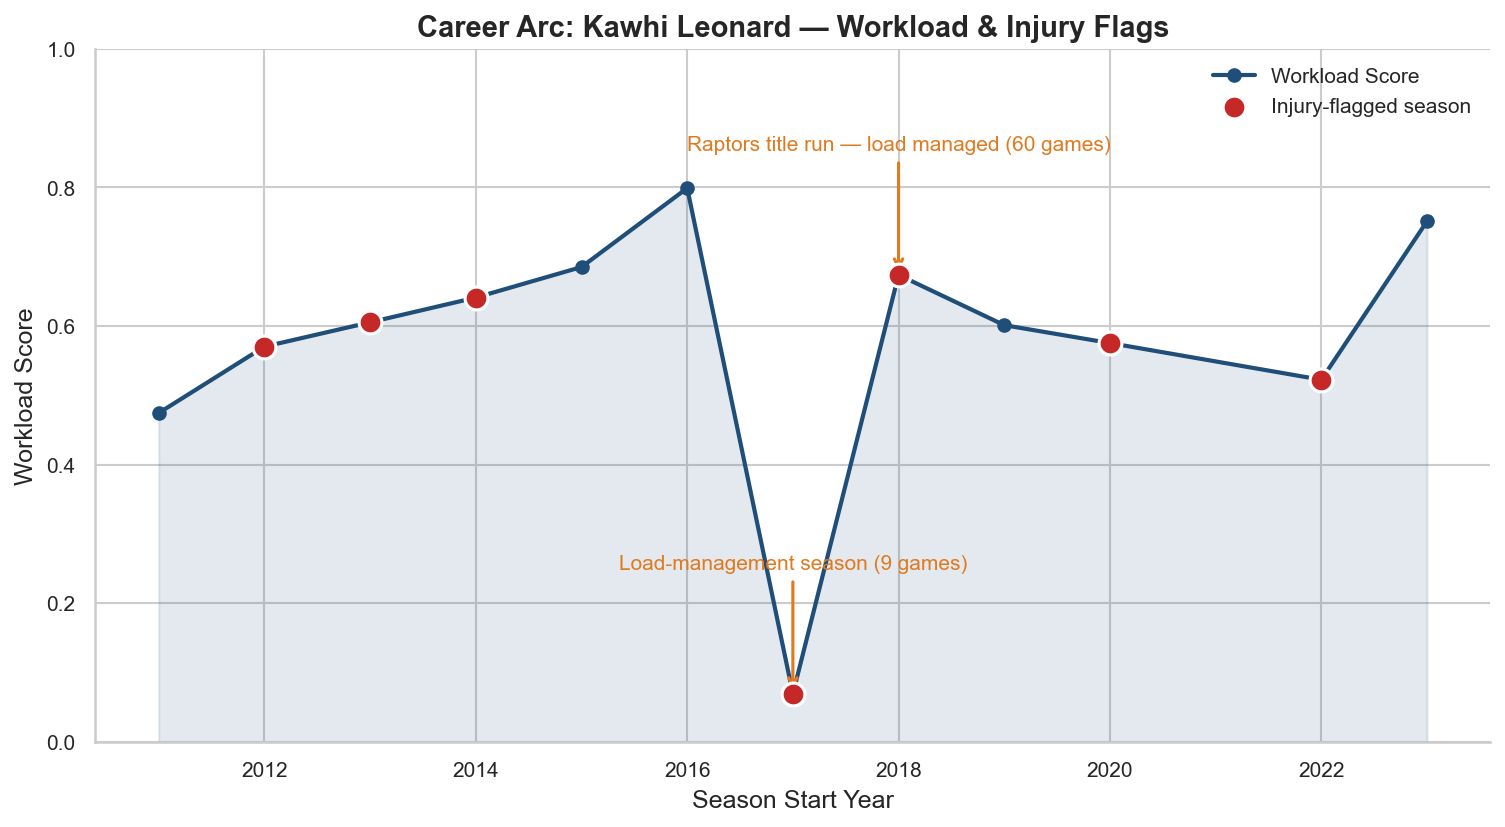

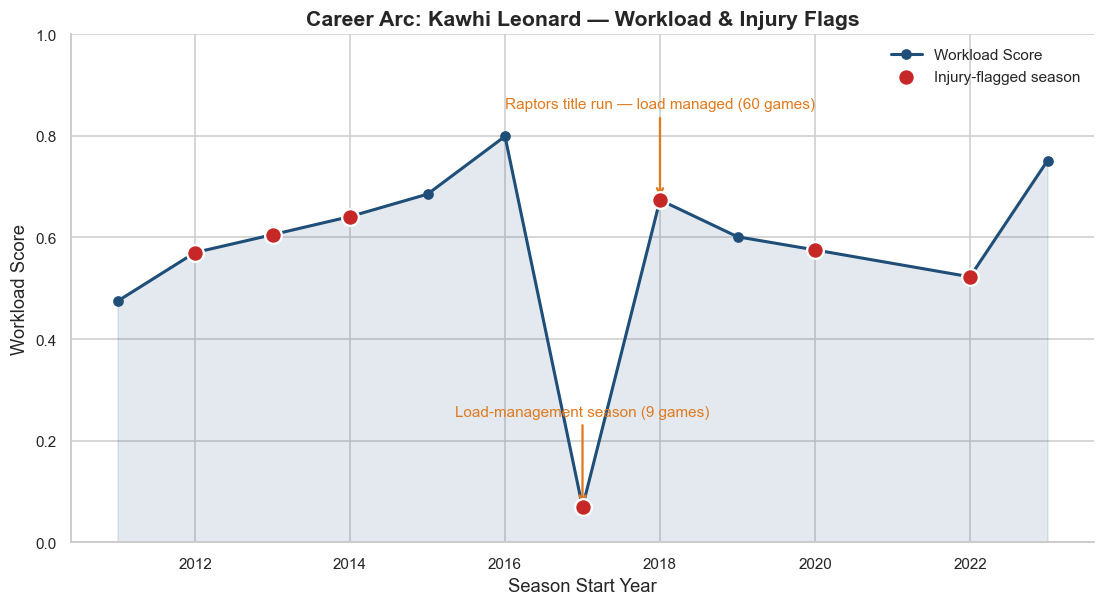

In [15]:
kawhi_annotations = {
    '2017-18': 'Load-management season (9 games)',
    '2018-19': 'Raptors title run — load managed (60 games)',
    '2021-22': 'ACL recovery — full season missed',
}
p = vz.plot_player_career(stats, 'kawhi leonard', annotations=kawhi_annotations)
print('saved:', os.path.relpath(p, PROJECT_ROOT))
Image(p)

## 10. Summary of EDA findings

Print the headline numbers used in `outputs/report.md` so they're reproducible from this notebook.

In [16]:
q = pd.qcut(stats['workload_score'].dropna(), q=5,
            labels=['Q1','Q2','Q3','Q4','Q5'])
rates = stats.assign(q=q).groupby('q', observed=True)['injury_flag'].mean() * 100
print('Injury rate by workload quintile (%):')
print(rates.round(1))
print()
print('Correlations with injury_flag:')
corr_with_inj = stats[['workload_score','age','per','usage_rate','injury_flag']].corr()['injury_flag'].drop('injury_flag')
print(corr_with_inj.round(3))
print()
by_era = stats.assign(era=stats['season_year']).groupby('era').agg(
    mean_workload=('workload_score','mean'),
    injury_rate=('injury_flag','mean')
)
print(f'Earliest season mean workload : {by_era.iloc[0]["mean_workload"]:.3f}')
print(f'Latest season mean workload   : {by_era.iloc[-1]["mean_workload"]:.3f}')
print(f'Earliest season injury rate   : {by_era.iloc[0]["injury_rate"]*100:.1f}%')
print(f'Latest season injury rate     : {by_era.iloc[-1]["injury_rate"]*100:.1f}%')

Injury rate by workload quintile (%):
q
Q1    39.3
Q2    38.8
Q3    33.3
Q4    27.9
Q5    13.5
Name: injury_flag, dtype: float64

Correlations with injury_flag:
workload_score   -0.205
age              -0.018
per               0.000
usage_rate       -0.014
Name: injury_flag, dtype: float64

Earliest season mean workload : 0.379
Latest season mean workload   : 0.335
Earliest season injury rate   : 30.6%
Latest season injury rate     : 0.0%
